In [1]:
import pandas as pd
import numpy as np

# 1. Load the data 
df = pd.read_csv('bank-additional-full.csv', sep=';')

print("Initial Shape:", df.shape)

# 2. Handling "Unknown" values
# The dataset uses the string 'unknown' instead of NaN. Let's make them real NaNs.
df.replace('unknown', np.nan, inplace=True)

# 3. Data Cleaning: Imputation
# We will fill categorical unknowns with the 'mode' (most frequent)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 4. Data Cleaning: Formatting
# Ensure age is integer and remove any potential whitespace from strings
df['job'] = df['job'].str.strip()

# 5. FEATURE ENGINEERING: Creating the "Profit" Metric
# Business Logic: 
# Cost per contact (duration is in seconds, we'll simplify cost per campaign attempt)
cost_per_contact = 5 
revenue_per_conversion = 100

# Calculate Net Profit
# If 'y' is yes, they converted.
df['Revenue'] = df['y'].apply(lambda x: revenue_per_conversion if x == 'yes' else 0)
df['Cost'] = cost_per_contact # Every row represents a contact attempt
df['Net_Profit'] = df['Revenue'] - df['Cost']

# 6. Create the TARGET Variable: Is_Profitable
# 1 = High Profit (Success), 0 = No Profit (Loss)
df['Is_Profitable'] = df['Net_Profit'].apply(lambda x: 1 if x > 0 else 0)

# 7. Drop the intermediate financial columns to prevent "Data Leakage"
# We don't want the model to see the Revenue or Net_Profit columns while training
df_cleaned = df.drop(columns=['Revenue', 'Cost', 'Net_Profit', 'y'])

# 8. Encode categorical variables for the model
df_final = pd.get_dummies(df_cleaned, drop_first=True)

print("Cleaned Shape:", df_final.shape)
df_final.head()

Initial Shape: (41188, 21)
Cleaned Shape: (41188, 48)


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False


In [2]:
from sklearn.preprocessing import StandardScaler

# List of numerical columns to scale
num_cols = ['age', 'duration', 'campaign', 'pdays', 'previous', 
            'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 
            'euribor3m', 'nr.employed']

scaler = StandardScaler()
df_final[num_cols] = scaler.fit_transform(df_final[num_cols])

print("Features Scaled Successfully.")

Features Scaled Successfully.


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

# 1. Separate the Profit and No Profit groups
df_no_profit = df_final[df_final['Is_Profitable'] == 0]
df_profit = df_final[df_final['Is_Profitable'] == 1]

print(f"Before Balancing - No Profit: {len(df_no_profit)}, Profit: {len(df_profit)}")

# 2. Downsample the 'No Profit' group to match the 'Profit' group size
df_no_profit_downsampled = resample(df_no_profit, 
                                     replace=False,    # sample without replacement
                                     n_samples=len(df_profit), # match minority class
                                     random_state=42)  # reproducible results

# 3. Combine them back together
df_balanced = pd.concat([df_no_profit_downsampled, df_profit])

# 4. Define X and y from the balanced dataframe
X = df_balanced.drop('Is_Profitable', axis=1)
y = df_balanced['Is_Profitable']

# 5. Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"After Balancing - Train size: {len(X_train)}, Test size: {len(X_test)}")
print("Target Distribution in Training Set:\n", y_train.value_counts())

Before Balancing - No Profit: 36548, Profit: 4640
After Balancing - Train size: 7424, Test size: 1856
Target Distribution in Training Set:
 Is_Profitable
0    3726
1    3698
Name: count, dtype: int64


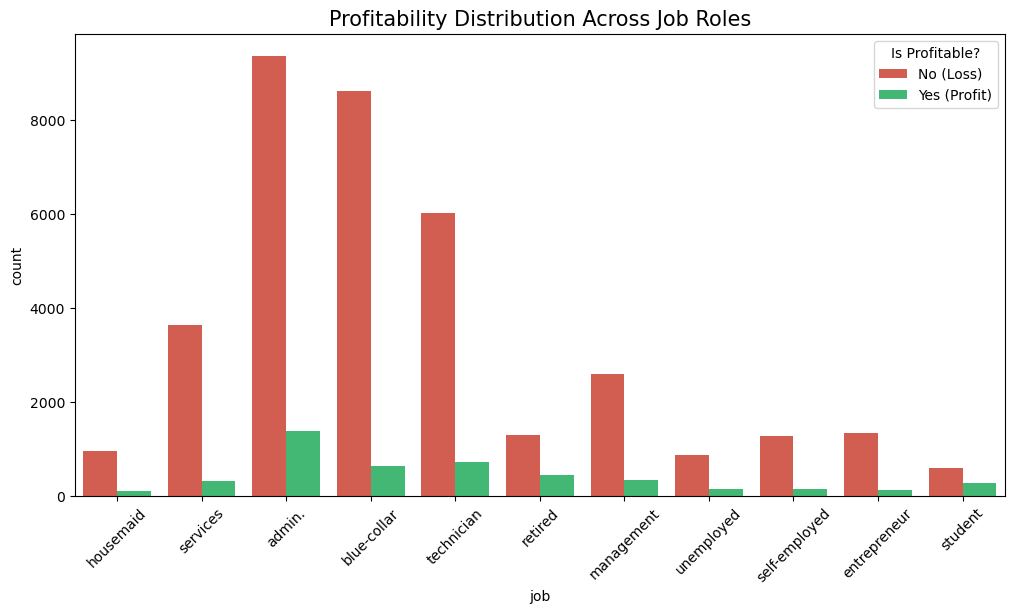

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a quick visual of Profitability by Job Category
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='job', hue='Is_Profitable', palette={1: '#2ecc71', 0: '#e74c3c'})
plt.title('Profitability Distribution Across Job Roles', fontsize=15)
plt.xticks(rotation=45)
plt.legend(title='Is Profitable?', labels=['No (Loss)', 'Yes (Profit)'])
plt.show()

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, f1_score

# 1. Baseline Model: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# 2. Random Forest (good for complex customer behavior)
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# 3. Gradient Boosting (Replaces XGBoost - built into sklearn)
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)

# Print comparison
models = {"Logistic Regression": lr_preds, "Random Forest": rf_preds, "Gradient Boosting": gb_preds}

for name, preds in models.items():
    print(f"\n--- {name} Performance ---")
    print(f"F1-Score (Profit): {round(f1_score(y_test, preds), 4)}")
    print(classification_report(y_test, preds))


--- Logistic Regression Performance ---
F1-Score (Profit): 0.8776
              precision    recall  f1-score   support

           0       0.88      0.86      0.87       914
           1       0.87      0.89      0.88       942

    accuracy                           0.87      1856
   macro avg       0.87      0.87      0.87      1856
weighted avg       0.87      0.87      0.87      1856


--- Random Forest Performance ---
F1-Score (Profit): 0.8965
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       914
           1       0.85      0.94      0.90       942

    accuracy                           0.89      1856
   macro avg       0.89      0.89      0.89      1856
weighted avg       0.89      0.89      0.89      1856


--- Gradient Boosting Performance ---
F1-Score (Profit): 0.8925
              precision    recall  f1-score   support

           0       0.92      0.85      0.88       914
           1       0.86      0.93      0.89 

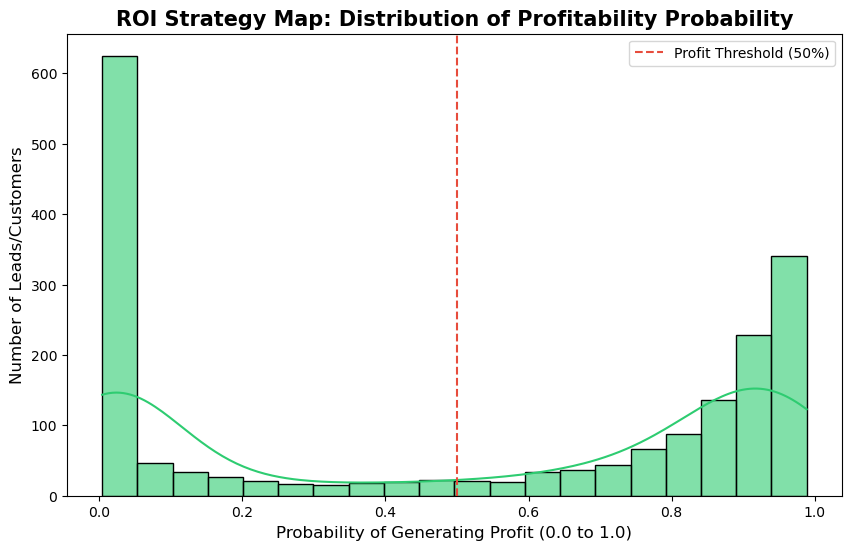

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use Gradient Boosting to predict probabilities
profit_probs = gb_model.predict_proba(X_test)[:, 1] 

plt.figure(figsize=(10, 6))
# We use Green because we are looking for the 'Green' (Profit) zone
sns.histplot(profit_probs, bins=20, kde=True, color='#2ecc71', alpha=0.6)

plt.title('ROI Strategy Map: Distribution of Profitability Probability', fontsize=15, fontweight='bold')
plt.xlabel('Probability of Generating Profit (0.0 to 1.0)', fontsize=12)
plt.ylabel('Number of Leads/Customers', fontsize=12) 

# The "Breakeven" Line
plt.axvline(0.5, color='#e74c3c', linestyle='--', label='Profit Threshold (50%)') 
plt.legend()
plt.show()

In [7]:
# Save the balanced and scaled training data
# This is the "Gold Standard" file for your project
X_train.to_csv('Advertising_ROI_Cleaned_Final.csv', index=False)

print("Success! Your cleaned and balanced dataset 'Advertising_ROI_Cleaned_Final.csv' is now in your folder.")

Success! Your cleaned and balanced dataset 'Advertising_ROI_Cleaned_Final.csv' is now in your folder.


In [8]:
import pandas as pd

# 1. Load the original raw data to get the 'y' column back
df_original = pd.read_csv('bank-additional-full.csv', sep=';')

# 2. Load your current cleaned CSV
df_cleaned = pd.read_csv('Advertising_ROI_Cleaned_Final.csv')

# 3. Add the 'y' column from the original data to the cleaned data
# Since the row order was preserved during cleaning/scaling, we can just assign it
df_cleaned['y_target'] = df_original['y']

# 4. Save the new version
df_cleaned.to_csv('Advertising_ROI_Cleaned_Final_v2.csv', index=False)

print("Success! The 'y_target' column has been added.")
print(df_cleaned[['y_target']].head())

Success! The 'y_target' column has been added.
  y_target
0       no
1       no
2       no
3       no
4       no
